In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, precision_score, f1_score
# from imblearn.over_sampling import SMOTE


In [3]:
path = "../Data/creditcard.csv"
df = pd.read_csv(path)

In [3]:
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [11]:

X = df.drop(columns=['Time', 'Class'])
y = df['Class']
class_weights = {0: 1, 1: 10}
lr = LogisticRegression(max_iter=2000, class_weight=class_weights)
dt = DecisionTreeClassifier(max_depth=3, min_samples_leaf=3, min_samples_split=5, max_features='log2')

In [ ]:
scores_r2_dt = cross_val_score(dt, X, y, scoring='r2')
scores_mse_dt = -cross_val_score(dt, X, y, scoring='neg_mean_squared_error')
scores_r2_lr = cross_val_score(lr, X, y, scoring='r2')
scores_mse_lr = -cross_val_score(lr, X, y, scoring='neg_mean_squared_error')

(np.float64(0.4051572620197459), np.float64(0.0011657027213519792))

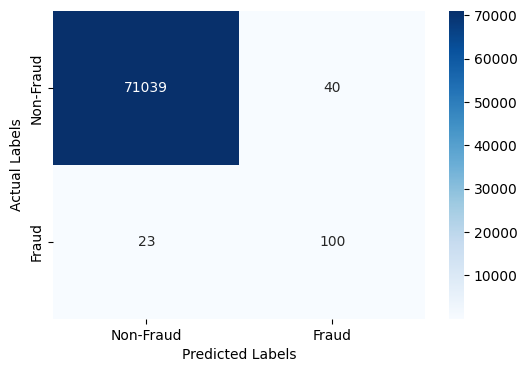

In [12]:
X_tran, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)
lr.fit(X_tran, y_train)
y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, cmap='Blues', fmt='d', annot=True, xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()


In [13]:
f1_score(y_test, y_pred)

0.7604562737642585